In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
def te(h, n):
    return h**n / math.factorial(n)

In [3]:
spacings = [-2, -1, 0, 1, 2, -1, 1]

In [4]:
t = [te(spacings[i], 2) for i in range(7)]

In [5]:
h = 1
M = np.array([
    [1, 1, 1, 1, 1, 0, 0],
    [te(-2*h, 0), te(-h, 0), 0, te(h, 0), te(2*h, 0), 1, 1],
    [te(-2*h, 1), te(-h, 1), 0, te(h, 1), te(2*h, 1), te(-h, 0), te(h, 0)],
    [te(-2*h, 2), te(-h, 2), 0, te(h, 2), te(2*h, 2), te(-h, 1), te(h, 1)],
    [te(-2*h, 3), te(-h, 3), 0, te(h, 3), te(2*h, 3), te(-h, 2), te(h, 2)],
    [te(-2*h, 4), te(-h, 4), 0, te(h, 4), te(2*h, 4), te(-h, 3), te(h, 3)],
    [te(-2*h, 5), te(-h, 5), 0, te(h, 5), te(2*h, 5), te(-h, 4), te(h, 4)],
             ])

In [6]:
T = np.zeros((7))

In [7]:
T[1] = 1

In [8]:
x = np.linalg.solve(M, T)

In [9]:
M.shape

(7, 7)

In [10]:
x

array([ 0.05555556,  0.44444444, -1.        ,  0.44444444,  0.05555556,
        0.33333333, -0.33333333])

In [11]:
x

array([ 0.05555556,  0.44444444, -1.        ,  0.44444444,  0.05555556,
        0.33333333, -0.33333333])

In [68]:
d = 2 * np.pi
res = 100
x = np.linspace(0, d, res, endpoint=False)



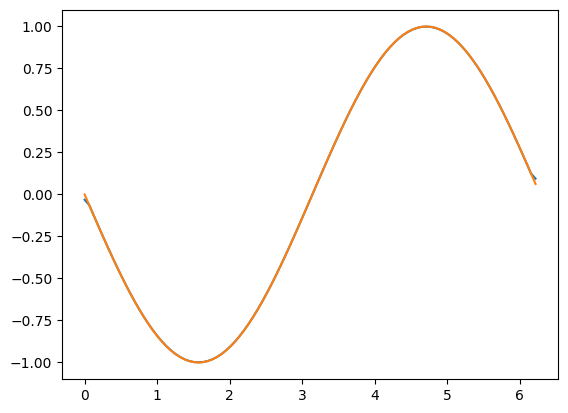

In [69]:
plt.plot(x, np.gradient(np.cos(x), d / (res)))
plt.plot(x, -np.sin(x))
plt.show()

In [70]:
def rmse(X, Y):
    return np.sqrt(np.mean((X - Y) ** 2))

def rel_rmse(X, Y):
    return rmse(X, Y) / rmse(Y, 0)

In [71]:
rel_rmse(np.gradient(np.cos(x), d / res), -np.sin(x))

np.float64(0.006305207905979548)

In [72]:
def derive_spectral(x, h):
    freq = np.fft.fftfreq(x.shape[0], d=h) * 2.0 * np.pi
    x_hat = np.fft.fft(x)
    x_hat_prime = x_hat * 1.0j * freq
    return np.fft.ifft(x_hat_prime).real

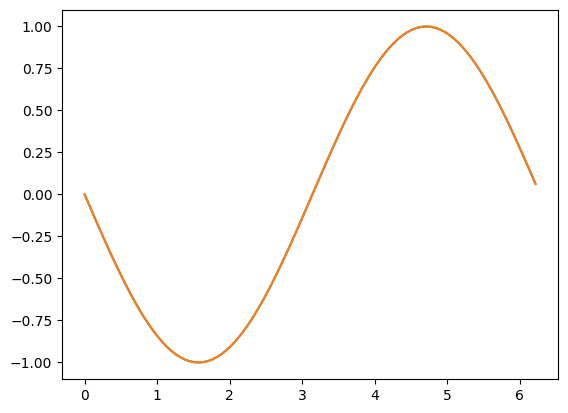

In [73]:
plt.plot(x, derive_spectral(np.cos(x), d / res))
plt.plot(x, -np.sin(x))
plt.show()

In [75]:
rel_rmse(derive_spectral(np.cos(x), d / res), -np.sin(x))

np.float64(7.149447458676944e-15)

In [250]:
from scipy.linalg import solve_banded
def derive_compact(field, direction, dy):
    field_reordered = np.moveaxis(field, direction, 0)
    shape_reordered = field_reordered.shape
    rhs = np.zeros_like(field_reordered)
    rhs[1:-1] = field_reordered[2:] - field_reordered[0:-2]
    rhs[0, ...] = 0
    rhs[-1, ...] = 0
    rhs *= 3.0 / dy
    f = field_reordered
    # rhs[0] = (-25*f[0] + 48*f[1] - 36*f[2] + 16*f[3] - 3*f[4]) / (12*dy)
    # rhs[-1] = (25*f[-1] - 48*f[-2] + 36*f[-3] - 16*f[-4] + 3*f[-5]) / (12*dy)
    length = field.shape[direction]
    ab = np.zeros((3, length))
    ab[0, 2:] = 1
    ab[1, :] = 4
    ab[2, :-2] = 1
    # BC
    ab[0, 1] = 0
    # ab[1, 0] = 1
    # ab[1, -1] = 1
    ab[2, -2] = 0
    rhs_reshaped = rhs.reshape(length, -1)
    field_prime_reshaped = solve_banded((1, 1), ab, rhs_reshaped)
    field_prime = np.moveaxis(field_prime_reshaped.reshape(shape_reordered), 0, direction)
    return field_prime

In [251]:
res = 50
x = np.linspace(0, d, res, endpoint=True)

In [252]:
v = derive_compact(np.cos(x), 0, d / res)

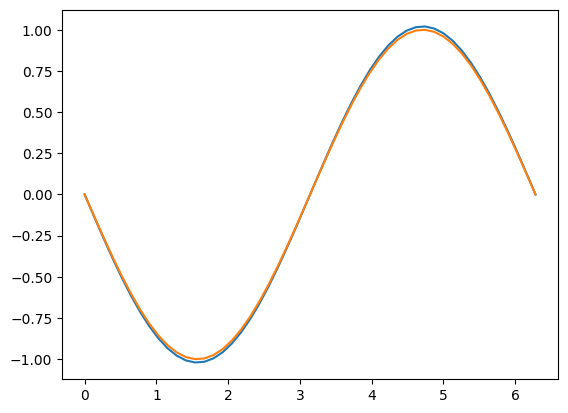

np.float64(0.020406627635049805)

In [253]:
plt.plot(x, v)
plt.plot(x, -np.sin(x))
plt.show()
rel_rmse(v, -np.sin(x))

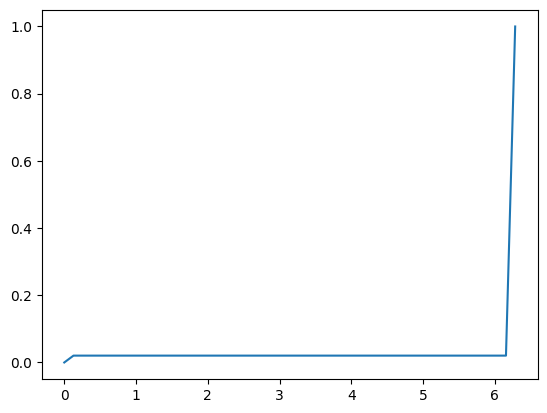

In [257]:
plt.plot(x, np.sqrt((v - -np.sin(x)) ** 2) / (np.sqrt((-np.sin(x)) ** 2) + 1e-20))
plt.show()

In [209]:
def derive_6th(x, h):
    rhs = np.zeros_like(x)
    rhs[1:-1] = x[:-2] - x[2:]
    rhs *= 1.0 * h / (3.0)
    ab = np.zeros((5, x.shape[0]))
    a = 1 / 18
    b = 4 / 9
    c = -1
    ab[0, 3:] = a
    ab[1, 2:] = b
    ab[2, :] = c
    ab[3, :-2] = b
    ab[4, :-3] = a
    x_prime = solve_banded((2, 2), ab, rhs)
    return x_prime

In [210]:
v = derive_6th(np.cos(x), d / res)

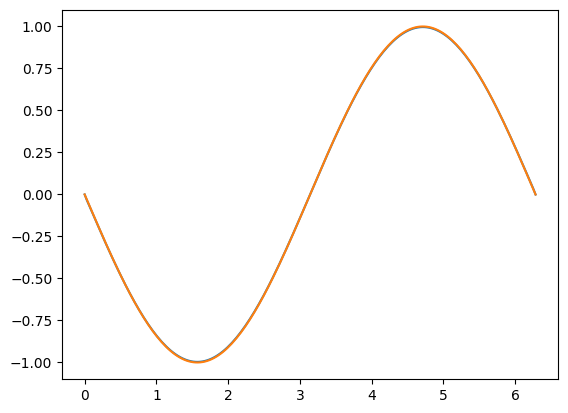

np.float64(0.003485063738258661)

In [211]:
plt.plot(x, v)
plt.plot(x, -np.sin(x))
plt.show()
rel_rmse(v, -np.sin(x))

In [239]:
from scipy.linalg import solve_banded
import numpy as np

def derive_compact_optionB(field, direction, dy):
    f = np.moveaxis(field, direction, 0)
    shape_reordered = f.shape
    n = f.shape[0]
    
    u0p = (-25*f[0] + 48*f[1] - 36*f[2] + 16*f[3] - 3*f[4]) / (12*dy)
    uNp = (25*f[-1] - 48*f[-2] + 36*f[-3] - 16*f[-4] + 3*f[-5]) / (12*dy)
    
    rhs = np.zeros_like(f)
    rhs[1:-1] = (f[2:] - f[0:-2]) * 3.0 / dy
    
    rhs[1] -= u0p
    rhs[-2] -= uNp
    
    ab = np.zeros((3, n-2))
    ab[0, 1:] = 1.0
    ab[1, :] = 4.0
    ab[2, :-1] = 1.0
    
    rhs_sub = rhs[1:-1].reshape(n-2, -1)
    prime_sub = solve_banded((1, 1), ab, rhs_sub)
    
    prime = np.zeros_like(f)
    prime[0] = u0p
    prime[-1] = uNp
    if prime_sub.ndim == 1:
        prime[1:-1] = prime_sub
    else:
        prime[1:-1] = prime_sub.reshape(n-2, -1).T
    
    return np.moveaxis(prime, 0, direction)


In [240]:
v = derive_compact_optionB(np.cos(x), 0, d / res)

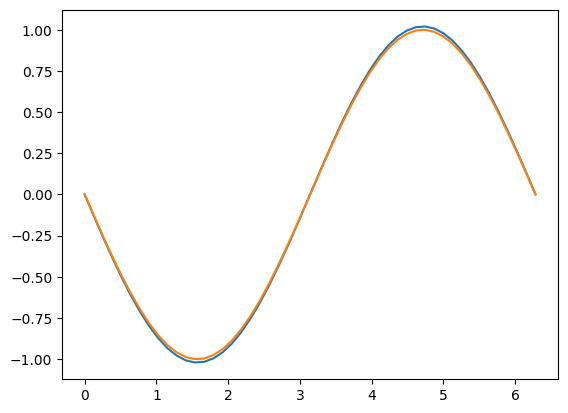

np.float64(0.020406648289571176)

In [241]:
plt.plot(x, v)
plt.plot(x, -np.sin(x))
plt.show()
rel_rmse(v, -np.sin(x))